# HR Workforce & Compensation Analysis

## Importing the required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset & Basic Exploration

### Loading the dataset

In [2]:
df = pd.read_csv("Employee_Profile_10500.csv")

df.head()

,S. No.,Employee Id,First Name,Last Name,Full Name,Gender,Marital Status,Age,Date Of Birth,Date Of Joining,Date of Leaving,Designation,Department,Work Location,Status,Qualification,Shift Details,Current CTC
0,1,ASG00001,Dhriti,Nagarajan,Dhriti Nagarajan,Female,Married,37,1988-10-26,2015-01-01,NaN,Regional Sales Lead,Sales,Kolkata,Active,UG,Day,1770000
1,2,ASG00002,Yashasvi,Vala,Yashasvi Vala,Female,Single,35,1991-06-19,2015-01-01,NaN,Sr Accountant,Finance,Mumbai,Active,UG,Mid,1620000
2,3,ASG00003,Charan,Kapoor,Charan Kapoor,Male,Single,43,1983-05-20,2015-01-02,NaN,Senior Payroll Analyst,Payroll,Chennai,Active,UG,Mid,2173000
3,4,ASG00004,Ucchal,Swaminathan,Ucchal Swaminathan,Female,Single,42,1983-11-06,2015-01-02,NaN,Regional Sales Lead,Sales,Chennai,Active,UG,Day,2054000
4,5,ASG00005,Thomas,Khatri,Thomas Khatri,Male,Married,40,1986-06-15,2015-01-03,NaN,Senior Sales Executive,Sales,Kolkata,Active,UG,Day,1974000


### Understanding the dataset

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.info()

Number of rows: 10500
Number of columns: 18
<class 'pandas.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   S. No.           10500 non-null  int64
 1   Employee Id      10500 non-null  str  
 2   First Name       10500 non-null  str  
 3   Last Name        10500 non-null  str  
 4   Full Name        10500 non-null  str  
 5   Gender           10500 non-null  str  
 6   Marital Status   10500 non-null  str  
 7   Age              10500 non-null  int64
 8   Date Of Birth    10500 non-null  str  
 9   Date Of Joining  10500 non-null  str  
 10  Date of Leaving  1783 non-null   str  
 11  Designation      10500 non-null  str  
 12  Department       10500 non-null  str  
 13  Work Location    10500 non-null  str  
 14  Status           10500 non-null  str  
 15  Qualification    10500 non-null  str  
 16  Shift Details    10500 non-null  str  
 17  Current CTC      

### Checking for missing values and duplicates

In [4]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal duplicate rows:", df.duplicated().sum())

Missing values in each column:
S. No.                0
Employee Id           0
First Name            0
Last Name             0
Full Name             0
Gender                0
Marital Status        0
Age                   0
Date Of Birth         0
Date Of Joining       0
Date of Leaving    8717
Designation           0
Department            0
Work Location         0
Status                0
Qualification         0
Shift Details         0
Current CTC           0
dtype: int64

Total duplicate rows: 0


### Data Exploration and Validation

In [5]:
print("Unique values in each column:")
print(df.nunique())

Unique values in each column:
S. No.             10500
Employee Id        10500
First Name           531
Last Name            538
Full Name          10500
Gender                 2
Marital Status         2
Age                   37
Date Of Birth       6277
Date Of Joining     3883
Date of Leaving     1271
Designation           20
Department             5
Work Location          5
Status                 2
Qualification          2
Shift Details          3
Current CTC         2437
dtype: int64


In [6]:
categorical_columns = [
    "Gender",
    "Marital Status",
    "Designation",
    "Department",
    "Work Location",
    "Status",
    "Qualification",
    "Shift Details"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


Gender:
Gender
Female    5346
Male      5154
Name: count, dtype: int64

Marital Status:
Marital Status
Married    6345
Single     4155
Name: count, dtype: int64

Designation:
Designation
Regional Sales Lead       1428
Senior Data Analyst       1099
Sr Accountant             1089
HR Analyst                 975
Senior Sales Executive     822
Senior Payroll Analyst     818
Data Analyst               576
Accounts Executive         536
Sales Executive            474
Payroll Analyst            453
HR Executive               347
Sales Manager              322
HR Manager                 254
Finance Manager            249
Analytics Manager          247
Accounts Trainee           194
BI Developer               170
Payroll Manager            156
Payroll Executive          153
Sales Trainee              138
Name: count, dtype: int64

Department:
Department
Sales        3184
Analytics    2092
Finance      2068
Payroll      1580
HR           1576
Name: count, dtype: int64

Work Location:
Work Locat

In [7]:
date_columns = [
    "Date Of Birth",
    "Date Of Joining",
    "Date of Leaving"
]

for column in date_columns:
    df[column] = pd.to_datetime(df[column], errors="coerce")

print(df[date_columns].dtypes)

Date Of Birth      datetime64[us]
Date Of Joining    datetime64[us]
Date of Leaving    datetime64[us]
dtype: object


In [8]:
print("Age range:", df["Age"].min(), "-", df["Age"].max())
print("CTC range:", df["Current CTC"].min(), "-", df["Current CTC"].max())

Age range: 22 - 58
CTC range: 450000 - 3800000


## Key Performance Indicators

### KPI 1 - Total Employees

In [9]:
total_employees = df["Employee Id"].nunique()

print("Total Employees:", total_employees)

Total Employees: 10500


Reason:
Shows the total workforce size and provides the base number for calculating other HR metrics.

Business insight:
The dataset contains 10,500 employees, giving a substantial workforce for analyzing employee demographics, departments, locations, and workforce trends.

### KPI 2 - Attrition Rate

In [10]:
attrition_rate = np.round(
    (df["Date of Leaving"].notna().sum() / len(df)) * 100, 2
)

print("Attrition Rate:", attrition_rate, "%")

Attrition Rate: 16.98 %


Reason:
Measures the percentage of employees who have left the organization and provides an overall view of workforce retention.

Business insight:
A higher attrition rate may indicate retention challenges and should be investigated further by department, location, designation, and employee tenure.

### KPI 3 - Average Tenure – Relieved Employees

In [11]:
relieved = df["Date of Leaving"].notna()

avg_tenure = (
    (df.loc[relieved, "Date of Leaving"] - df.loc[relieved, "Date Of Joining"])
    .dt.days / 365.25
).mean()

print("Average Tenure of Relieved Employees:", round(avg_tenure, 1), "years")

Average Tenure of Relieved Employees: 3.2 years


Reason: Measures how long relieved employees stayed with the organization before leaving, helping understand employee retention patterns.

Business insight: A shorter average tenure among relieved employees may indicate that employees are leaving relatively early, while a longer average tenure suggests employees tend to stay with the organization for a longer period before leaving.

### KPI 4 - Average CTC: Active vs Relieved

In [12]:
avg_ctc = df.groupby("Status")["Current CTC"].mean().round(0)

print("Average CTC:")
print(avg_ctc)

Average CTC:
Status
Active      1690327.0
Relieved    1700474.0
Name: Current CTC, dtype: float64


Reason:
To compare the average compensation of active and relieved employees and understand whether there is a noticeable salary difference between the two groups.

Business Insight:
If relieved employees have a considerably lower average CTC, compensation could be one area worth investigating. However, this shows an association and does not prove that CTC caused employees to leave.

### KPI 5 - Employees per Department: Active vs Relieved

In [13]:
department_status = pd.crosstab(
    df["Department"],
    df["Status"]
)

print("Employees per Department:")
print(department_status)

Employees per Department:
Status      Active  Relieved
Department                  
Analytics     1775       317
Finance       1719       349
HR            1291       285
Payroll       1290       290
Sales         2642       542


Reason: Compares active and relieved employees across departments to understand department-wise workforce strength and employee movement.

Business insight: Departments with a high number of relieved employees may require further investigation for retention or workforce-management issues, while departments with more active employees may indicate stronger workforce stability.

## Visualizations

### Visualization 1 - Employees by Shift and Status

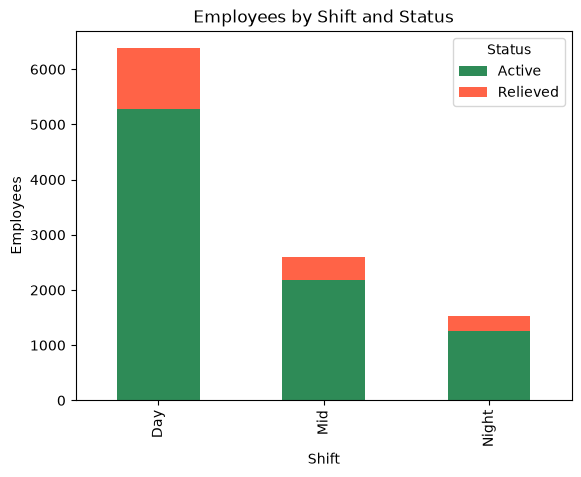

In [14]:
pd.crosstab(df["Shift Details"], df["Status"]).plot(
    kind="bar", stacked=True, color=["seagreen", "tomato"]
)

plt.title("Employees by Shift and Status")
plt.xlabel("Shift")
plt.ylabel("Employees")
plt.show()

Reason:
To compare active and relieved employees across different work shifts.

Business Insight:
This can highlight shifts with relatively higher numbers of relieved employees and help HR investigate whether shift patterns may be associated with employee retention.

### Visualization 2 - Top 10 Designations by Work Location

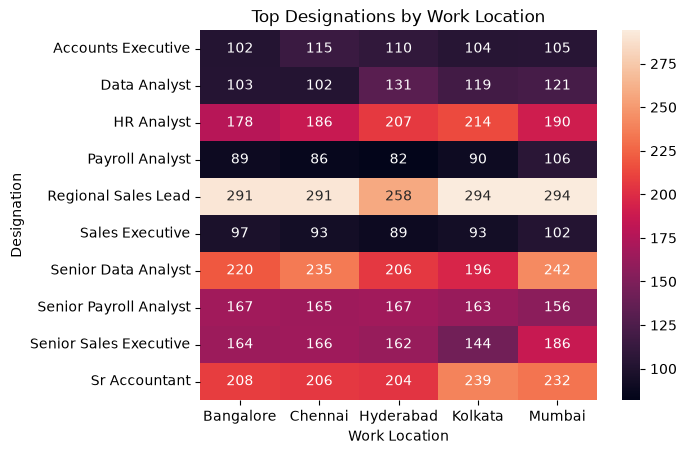

In [15]:
top10 = df["Designation"].value_counts().head(10).index
filtered = df[df["Designation"].isin(top10)]

sns.heatmap(pd.crosstab(filtered["Designation"], filtered["Work Location"]), annot=True, fmt="d")
plt.title("Top Designations by Work Location")
plt.show()

Reason:
To identify where the organization's major job roles are concentrated geographically.

Business Insight:
The heatmap makes it easy to identify locations with high concentrations of particular designations, which can support workforce allocation and location planning.

### Visualization 3 - Joining vs Relieving Trend

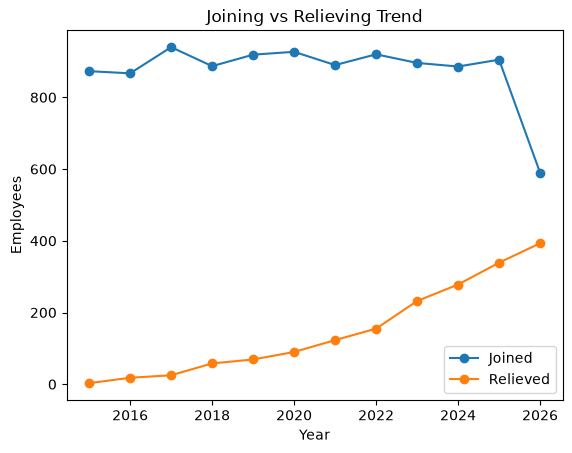

In [16]:
joining = df["Date Of Joining"].dt.year.value_counts().sort_index()
leaving = df["Date of Leaving"].dropna().dt.year.value_counts().sort_index()

plt.plot(joining.index, joining.values, marker="o", label="Joined")
plt.plot(leaving.index, leaving.values, marker="o", label="Relieved")

plt.title("Joining vs Relieving Trend")
plt.xlabel("Year")
plt.ylabel("Employees")
plt.legend()
plt.show()

Reason:
To compare employee additions and exits over time.

Business Insight:
When relieving numbers are considerably higher than joining numbers in a particular period, it may indicate workforce contraction or increased employee turnover during that period.

### Visualization 4 - Marital Status Distribution

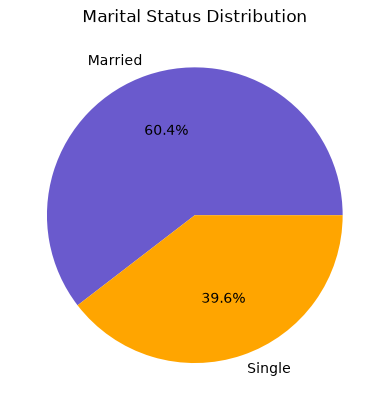

In [17]:
marital_count = df["Marital Status"].value_counts()
plt.pie(marital_count.values, labels=marital_count.index, autopct="%1.1f%%", colors=["#6A5ACD", "#FFA500"])
plt.title("Marital Status Distribution")
plt.show()

Reason: Shows what share of employees are single vs. married.

Business Insight: Useful for planning benefits like family health insurance or parental leave policies, since demand for these depends on how many employees are married.

### Visualization 5 - Age Status Distribution

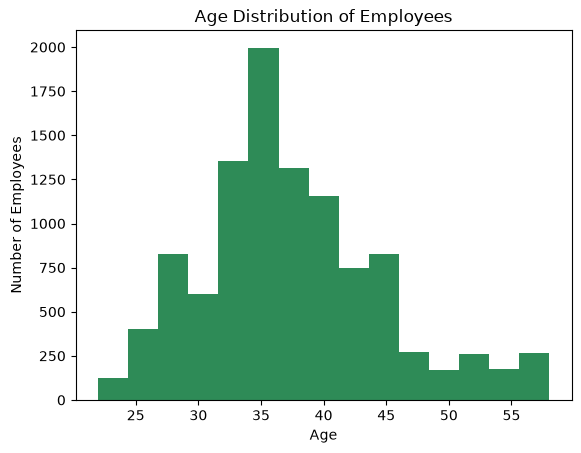

In [18]:
plt.hist(df["Age"], bins=15, color="#2E8B57")
plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.show()

Reason: Shows whether the workforce skews younger or older overall.

Business Insight: A workforce clustered at younger ages may need more training investment, while an older-skewing one raises succession-planning questions for senior roles.

## Conclusion / Key Takeaways

This analysis provided an overall view of the organization's workforce, employee attrition, tenure, compensation, and workforce structure. The analysis of employee data helped identify important patterns across different employee groups, departments, work locations, designations, and time periods.

The KPIs and visualizations provide useful insights into workforce composition, employee movement, compensation patterns, and areas that may require further HR investigation. These findings can support HR teams in workforce planning, retention analysis, and data-driven decision-making.

Overall, the project demonstrates how Python can be used to clean, analyze, visualize, and interpret HR data and convert raw employee information into meaningful business insights.